# Indice de vulnérabilité « Infrastructures » — Éducation Togo

Construction et **validation** d'un indice composite d'infrastructures, calculable jusqu'à la **commune** (117 communes), à partir du registre géolocalisé (**extraction du 18/12/2024**).

**Variables retenues** (5) : nombre d'établissements, toilettes/école, bâtiments/école, % écoles avec terrain de sport, ancienneté moyenne des bâtiments.

**Plan :** agrégation → stats → corrélations → normalisation → indice pondéré → ACP → **validation (Cronbach, Bartlett, KMO, scree)** → **cercle de corrélation** → **projection des individus** → classement → carte.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

BASE = 'data' if os.path.isdir('data') else os.path.join('..', 'data')
GEO  = 'data_togo' if os.path.isdir('data_togo') else os.path.join('..', 'data_togo')
ANNEE_REF = 2024   # les fichiers du registre ont ete extraits le 18/12/2024

def lire(nom):
    return pd.read_csv(os.path.join(BASE, nom), low_memory=False)

etab = lire('01-etablissements-scolaires.csv')
toil = lire('02-toilettes-scolaires.csv')
bat  = lire('03-batiments-electrification.csv')
print('etablissements :', etab.shape, '| toilettes :', toil.shape, '| batiments :', bat.shape)

etablissements : (15454, 15) | toilettes : (10228, 8) | batiments : (28055, 9)


## 1. Agrégation par commune

- `ecoles` = nombre d'établissements (comptage des lignes du registre).
- `toil_par_ecole`, `bat_par_ecole` = **densités** (total blocs / total écoles ; total bâtiments / total écoles) — NB : les toilettes/bâtiments ne sont pas rattachables à une école précise, c'est une moyenne communale.
- `sport_pct` = **% d'écoles** avec `terrain_sport = 'Oui'` (attribut direct par école).
- `age_moyen` = ancienneté moyenne des bâtiments (année de réf. 2024 ; années de construction 1950-2022).

*(La variable « bibliothèques » a été retirée de l'indice ; le nombre d'établissements a été ajouté.)*

In [2]:
KEYS = ['region_nom_bdd', 'prefecture_nom_bdd', 'commune_nom_bdd']

g = etab.groupby(KEYS)
com = pd.DataFrame({'ecoles': g.size()})
com['sport_oui'] = etab[etab['terrain_sport'] == 'Oui'].groupby(KEYS).size()
com['toilettes'] = toil.groupby(KEYS).size()
com['batiments'] = bat.groupby(KEYS).size()

ba = bat[KEYS + ['batiment_annee']].copy()
ba['an'] = pd.to_numeric(ba['batiment_annee'], errors='coerce')
ba = ba[(ba['an'] >= 1950) & (ba['an'] <= ANNEE_REF)]
com['age_moyen'] = ANNEE_REF - ba.groupby(KEYS)['an'].mean()

com = com.fillna(0).reset_index()
com['toil_par_ecole'] = com['toilettes'] / com['ecoles']
com['bat_par_ecole']  = com['batiments'] / com['ecoles']
com['sport_pct']      = com['sport_oui'] / com['ecoles'] * 100

IND = ['ecoles', 'toil_par_ecole', 'bat_par_ecole', 'sport_pct', 'age_moyen']
print(len(com), 'communes')
com[['region_nom_bdd', 'prefecture_nom_bdd', 'commune_nom_bdd'] + IND].head()

117 communes


,region_nom_bdd,prefecture_nom_bdd,commune_nom_bdd,ecoles,toil_par_ecole,bat_par_ecole,sport_pct,age_moyen
0,Centrale,Blitta,Blitta 1,166,1.132530,1.921687,31.325301,16.012397
1,Centrale,Blitta,Blitta 2,120,0.941667,2.033333,40.000000,15.256684
2,Centrale,Blitta,Blitta 3,132,0.492424,1.719697,28.030303,13.892473
3,Centrale,Mô,Mô 1,65,0.723077,1.769231,40.000000,10.682927
4,Centrale,Mô,Mô 2,39,0.820513,1.743590,51.282051,11.035088


## 2. Statistiques descriptives

In [3]:
com[IND].describe().round(2)

,ecoles,toil_par_ecole,bat_par_ecole,sport_pct,age_moyen
count,117.00,117.00,117.00,117.00,117.00
mean,132.09,0.68,1.91,33.43,17.49
std,107.88,0.19,0.34,12.29,5.15
min,27.00,0.24,1.08,6.17,9.08
25%,69.00,0.55,1.74,25.29,13.81
50%,106.00,0.68,1.91,34.86,16.42
75%,156.00,0.79,2.12,41.67,20.52
max,697.00,1.23,2.84,65.81,37.00


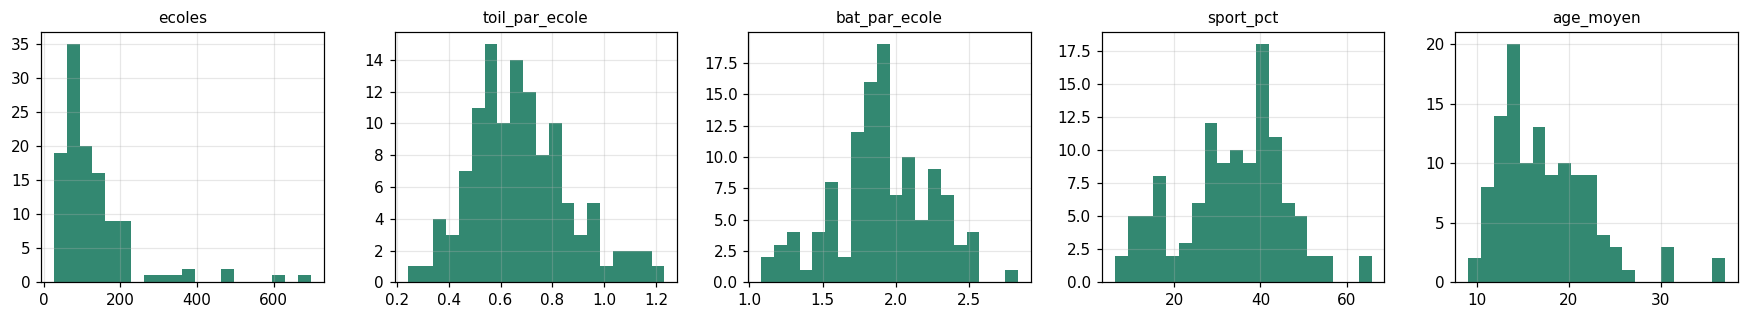

In [4]:
fig, axes = plt.subplots(1, len(IND), figsize=(16, 3))
for ax, k in zip(axes, IND):
    ax.hist(com[k], bins=20, color='#006A4E', alpha=0.8); ax.set_title(k, fontsize=10)
plt.tight_layout(); plt.show()

## 3. Corrélations (redondance)

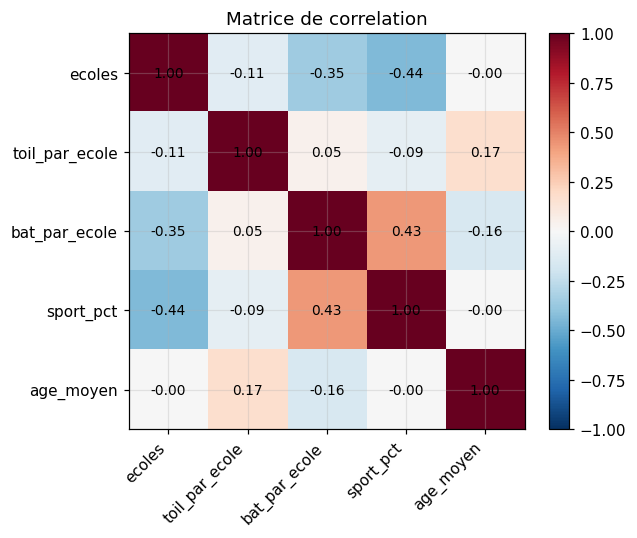

In [5]:
corr = com[IND].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(IND))); ax.set_xticklabels(IND, rotation=45, ha='right')
ax.set_yticks(range(len(IND))); ax.set_yticklabels(IND)
for i in range(len(IND)):
    for j in range(len(IND)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, fraction=0.046); plt.title('Matrice de correlation'); plt.tight_layout(); plt.show()

## 4. Normalisation 0–100 (min-max + winsorisation)

Toutes les variables orientées « + = mieux équipé ». `age_moyen` (plus = pire) est **inversé**.

In [6]:
def winsor(s, p=0.05):
    return s.clip(s.quantile(p), s.quantile(1 - p))

def minmax(s):
    s = winsor(s)
    return (s - s.min()) / (s.max() - s.min()) * 100 if s.max() != s.min() else s * 0

N = pd.DataFrame(index=com.index)
for k in ['ecoles', 'toil_par_ecole', 'bat_par_ecole', 'sport_pct']:
    N[k] = minmax(com[k])
N['age_moyen'] = 100 - minmax(com['age_moyen'])   # inversion
N.describe().round(1)

,ecoles,toil_par_ecole,bat_par_ecole,sport_pct,age_moyen
count,117.0,117.0,117.0,117.0,117.0
mean,28.2,42.9,53.5,56.7,57.3
std,25.3,26.9,27.0,29.7,29.3
min,0.0,0.0,0.0,0.0,0.0
25%,10.1,23.9,38.7,36.1,34.5
50%,22.2,42.7,53.4,61.3,62.7
75%,38.5,59.7,71.5,79.2,80.7
max,100.0,100.0,100.0,100.0,100.0


## 5. Pondération et indice composite

`Score équipement = 0,30·toilettes + 0,20·bâtiments + 0,20·sport + 0,20·ancienneté(inv.) + 0,10·nb établissements`
`Vulnérabilité = 100 − Score équipement`  (élevé = à prioriser).

In [7]:
POIDS = {'toil_par_ecole': 0.30, 'bat_par_ecole': 0.20, 'sport_pct': 0.20,
         'age_moyen': 0.20, 'ecoles': 0.10}
assert abs(sum(POIDS.values()) - 1) < 1e-9

com['score_equipement'] = sum(N[k] * w for k, w in POIDS.items())
com['vulnerabilite'] = 100 - com['score_equipement']
com.sort_values('vulnerabilite', ascending=False)[
    ['region_nom_bdd', 'prefecture_nom_bdd', 'commune_nom_bdd', 'ecoles',
     'score_equipement', 'vulnerabilite']].head(10).round(1)

,region_nom_bdd,prefecture_nom_bdd,commune_nom_bdd,ecoles,score_equipement,vulnerabilite
98,Plateaux,Wawa,Wawa 1,134,19.8,80.2
79,Plateaux,Danyi,Danyi 2,81,20.4,79.6
47,Maritime,Golfe,Golfe 1,697,24.2,75.8
99,Plateaux,Wawa,Wawa 2,66,24.7,75.3
78,Plateaux,Danyi,Danyi 1,77,26.7,73.3
50,Maritime,Golfe,Golfe 4,207,27.2,72.8
87,Plateaux,Kloto,Kloto 1,201,27.4,72.6
39,Maritime,Agoè-Nyivé,Agoè-Nyivé 3,88,27.8,72.2
89,Plateaux,Kloto,Kloto 3,44,29.0,71.0
56,Maritime,Lacs,Lacs 3,218,29.4,70.6


## 6. ACP — axes latents

On standardise `N`, on diagonalise la matrice de covariance et on calcule les scores (coordonnées des communes) et les valeurs propres.

In [8]:
X = (N - N.mean()) / N.std()
C = np.cov(X.values.T)
vals, vecs = np.linalg.eigh(C)
order = np.argsort(vals)[::-1]
vals, vecs = vals[order], vecs[:, order]
scores = X.values @ vecs                    # coordonnees des communes
pc1, pc2 = vals[0] / vals.sum() * 100, vals[1] / vals.sum() * 100
print('Variance expliquee :', (vals / vals.sum() * 100).round(1), '%')
print(f'PC1 = {pc1:.1f} %  |  PC2 = {pc2:.1f} %  |  PC1+PC2 = {pc1 + pc2:.1f} %')

Variance expliquee : [36.2 23.4 18.8 12.6  9. ] %
PC1 = 36.2 %  |  PC2 = 23.4 %  |  PC1+PC2 = 59.7 %


## 7. Validation statistique

- **Alpha de Cronbach** : cohérence interne (un indice *formatif* à dimensions complémentaires peut avoir un alpha faible — c'est attendu).
- **Bartlett** & **KMO** : les données sont-elles factorisables ?
- **Scree plot** : nombre d'axes utiles (critère de Kaiser, valeur propre > 1).

In [9]:
def cronbach_alpha(df):
    k = df.shape[1]
    return (k / (k - 1)) * (1 - df.var(ddof=1).sum() / df.sum(axis=1).var(ddof=1))

print(f'Alpha de Cronbach ({N.shape[1]} variables) : {cronbach_alpha(N):.3f}')
print('Alpha si la variable est retiree :')
for c in N.columns:
    print(f'  sans {c:16s} -> {cronbach_alpha(N.drop(columns=c)):.3f}')

Alpha de Cronbach (5 variables) : -0.295
Alpha si la variable est retiree :
  sans ecoles           -> 0.195
  sans toil_par_ecole   -> -0.152
  sans bat_par_ecole    -> -0.936
  sans sport_pct        -> -0.249
  sans age_moyen        -> -0.398


In [10]:
from scipy.stats import chi2

def bartlett(df):
    n, p = df.shape
    R = df.corr().values
    stat = -(n - 1 - (2 * p + 5) / 6) * np.log(np.linalg.det(R))
    return stat, chi2.sf(stat, p * (p - 1) / 2)

def kmo(df):
    R = df.corr().values; Ri = np.linalg.inv(R)
    d = np.sqrt(np.diag(Ri)); P = -Ri / np.outer(d, d)
    R0 = R.copy(); np.fill_diagonal(R0, 0)
    P0 = P.copy(); np.fill_diagonal(P0, 0)
    return np.sum(R0 ** 2) / (np.sum(R0 ** 2) + np.sum(P0 ** 2))

s, p = bartlett(N)
print(f'Bartlett : chi2 = {s:.1f} | p = {p:.2e} -> {"factorisable" if p < 0.05 else "non factorisable"}')
print(f'KMO      : {kmo(N):.3f}  (>0.6 acceptable, >0.8 tres bon)')

Bartlett : chi2 = 65.3 | p = 3.52e-10 -> factorisable
KMO      : 0.552  (>0.6 acceptable, >0.8 tres bon)


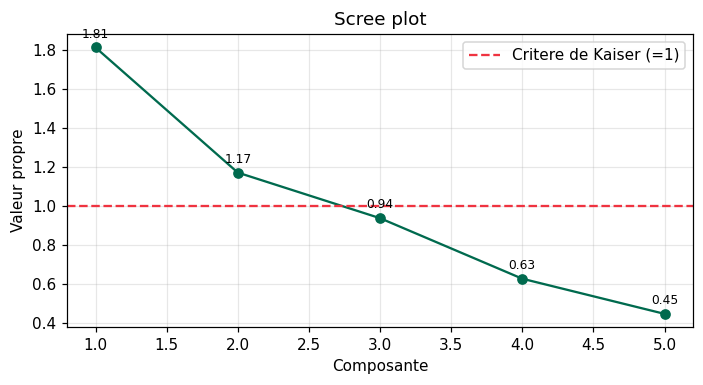

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
xs = range(1, len(vals) + 1)
ax.plot(xs, vals, 'o-', color='#006A4E')
ax.axhline(1, ls='--', color='#EF3340', label='Critere de Kaiser (=1)')
for x, v in zip(xs, vals):
    ax.text(x, v + 0.05, f'{v:.2f}', ha='center', fontsize=8)
ax.set_xlabel('Composante'); ax.set_ylabel('Valeur propre'); ax.set_title('Scree plot')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Cercle de corrélation

Coordonnées d'une variable = sa **corrélation** avec PC1 (x) et PC2 (y).
Flèches dans la même direction ⇒ corrélées ; à 90° ⇒ indépendantes ; opposées ⇒ anti-corrélées. Plus la flèche est longue (proche du cercle), mieux la variable est représentée.

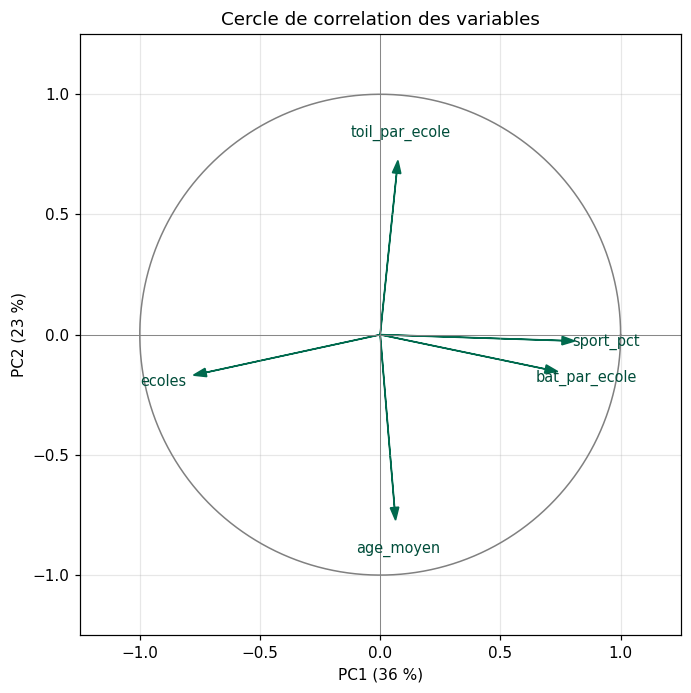

                axe_PC1  axe_PC2  communalite_2axes
ecoles            -0.78    -0.17               0.63
toil_par_ecole     0.07     0.72               0.53
bat_par_ecole      0.74    -0.15               0.57
sport_pct          0.81    -0.03               0.65
age_moyen          0.06    -0.77               0.60


In [12]:
cx = np.array([np.corrcoef(X.iloc[:, j], scores[:, 0])[0, 1] for j in range(X.shape[1])])
cy = np.array([np.corrcoef(X.iloc[:, j], scores[:, 1])[0, 1] for j in range(X.shape[1])])

fig, ax = plt.subplots(figsize=(6.4, 6.4))
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th), np.sin(th), color='gray', lw=1)
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
for j, nom in enumerate(X.columns):
    ax.arrow(0, 0, cx[j], cy[j], color='#006A4E', head_width=0.035, length_includes_head=True)
    ax.text(cx[j] * 1.16, cy[j] * 1.16, nom, ha='center', va='center', fontsize=9.5, color='#004D3A')
ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25); ax.set_aspect('equal')
ax.set_xlabel(f'PC1 ({pc1:.0f} %)'); ax.set_ylabel(f'PC2 ({pc2:.0f} %)')
ax.set_title('Cercle de correlation des variables'); plt.tight_layout(); plt.show()

comm = pd.DataFrame({'axe_PC1': cx, 'axe_PC2': cy,
                     'communalite_2axes': cx ** 2 + cy ** 2}, index=X.columns).round(2)
print(comm)

## 9. Projection des individus (communes)

Chaque point est une **commune**, positionnée par ses scores (PC1, PC2), colorée par région. On superpose le nom des communes les plus extrêmes. À lire **avec** le cercle de corrélation : une commune à droite est « riche » sur les variables pointant à droite.

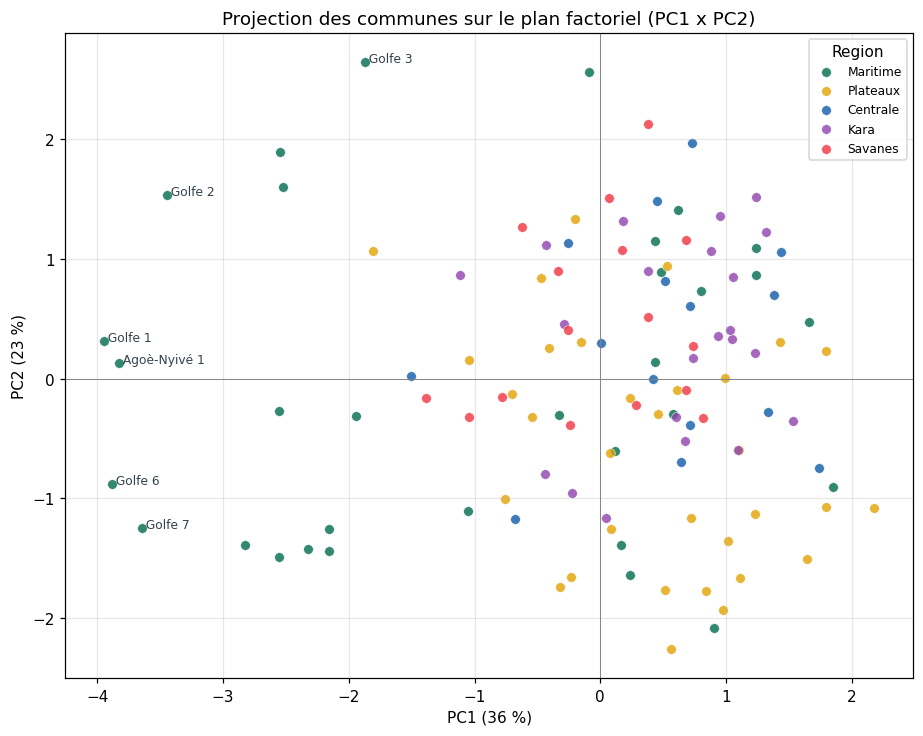

In [13]:
PALETTE = {'Maritime': '#006A4E', 'Plateaux': '#E1A100', 'Centrale': '#0F5AA8',
           'Kara': '#8E44AD', 'Savanes': '#EF3340'}
regions = com['region_nom_bdd'].values

fig, ax = plt.subplots(figsize=(8.5, 6.8))
for reg, coul in PALETTE.items():
    m = regions == reg
    ax.scatter(scores[m, 0], scores[m, 1], c=coul, label=reg, s=40, alpha=0.8,
               edgecolor='white', linewidth=0.4)
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
# etiqueter les 6 communes les plus eloignees de l'origine
dist = np.hypot(scores[:, 0], scores[:, 1])
for i in np.argsort(dist)[-6:]:
    ax.text(scores[i, 0], scores[i, 1], ' ' + com['commune_nom_bdd'].iloc[i], fontsize=8, color='#33414D')
ax.set_xlabel(f'PC1 ({pc1:.0f} %)'); ax.set_ylabel(f'PC2 ({pc2:.0f} %)')
ax.set_title('Projection des communes sur le plan factoriel (PC1 x PC2)')
ax.legend(title='Region', fontsize=8); plt.tight_layout(); plt.show()

## 10. Classement & quintiles

priorite
Tres performant     24
Performant          23
Modere              23
Prioritaire         23
Tres prioritaire    24
Name: count, dtype: int64


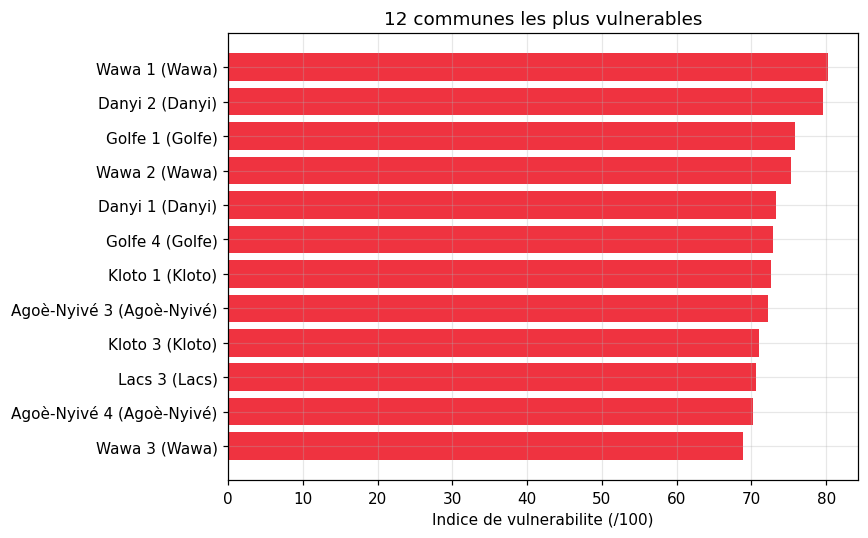

In [14]:
com['priorite'] = pd.qcut(com['vulnerabilite'], 5,
    labels=['Tres performant', 'Performant', 'Modere', 'Prioritaire', 'Tres prioritaire'])
print(com['priorite'].value_counts().sort_index())

top = com.sort_values('vulnerabilite', ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8, 5))
lib = top['commune_nom_bdd'] + ' (' + top['prefecture_nom_bdd'] + ')'
ax.barh(lib[::-1], top['vulnerabilite'][::-1], color='#EF3340')
ax.set_xlabel('Indice de vulnerabilite (/100)'); ax.set_title('12 communes les plus vulnerables')
plt.tight_layout(); plt.show()

## 11. Agrégation préfecture / région (pondérée par le nb d'écoles) + carte

In [15]:
def agreger(df, col):
    w = df['ecoles']
    out = df.assign(_w=df['vulnerabilite'] * w).groupby(col).agg(
        ecoles=('ecoles', 'sum'), _w=('_w', 'sum'))
    out['vulnerabilite'] = (out['_w'] / out['ecoles']).round(1)
    return out.drop(columns='_w').sort_values('vulnerabilite', ascending=False)

print('=== Par region ==='); print(agreger(com, 'region_nom_bdd'))
print('\n=== Top 10 prefectures ==='); print(agreger(com, 'prefecture_nom_bdd').head(10))

=== Par region ===
                ecoles  vulnerabilite
region_nom_bdd                       
Maritime          6654           59.7
Plateaux          3339           54.7
Kara              1952           50.5
Centrale          1700           41.5
Savanes           1809           40.8

=== Top 10 prefectures ===
                    ecoles  vulnerabilite
prefecture_nom_bdd                       
Danyi                  158           76.5
Wawa                   295           75.5
Kloto                  311           70.6
Golfe                 2403           68.2
Agoè-Nyivé            1358           66.6
Agou                   218           65.0
Lacs                   447           61.6
Amou                   270           59.6
Binah                  208           56.8
Akébou                 201           56.7


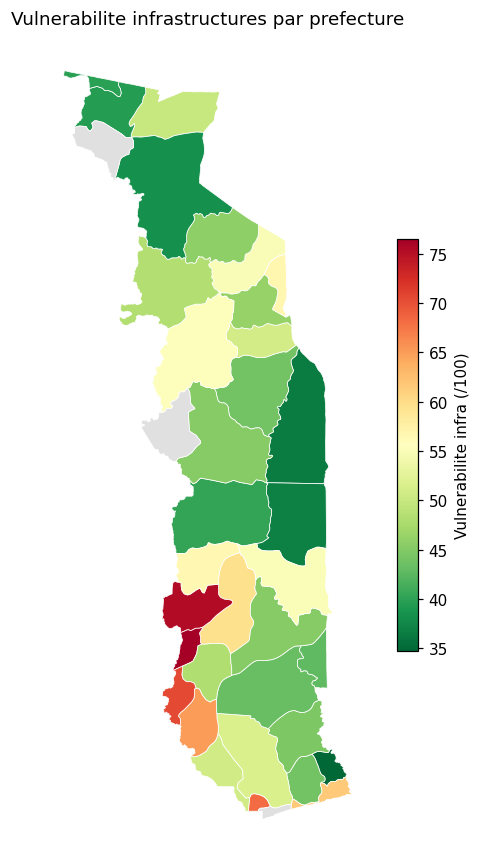

In [16]:
try:
    import geopandas as gpd, unicodedata
    def nrm(s): return ''.join(c for c in unicodedata.normalize('NFD', str(s).lower().strip())
                               if unicodedata.category(c) != 'Mn')
    pref = agreger(com, 'prefecture_nom_bdd').reset_index()
    gj = gpd.read_file(os.path.join(GEO, 'togo_prefectures.geojson'))
    gj['k'] = gj['shapeName'].map(nrm); pref['k'] = pref['prefecture_nom_bdd'].map(nrm)
    gj = gj.merge(pref[['k', 'vulnerabilite']], on='k', how='left')
    ax = gj.plot(column='vulnerabilite', cmap='RdYlGn_r', legend=True, edgecolor='white',
                 linewidth=0.5, figsize=(6, 8), missing_kwds={'color': '#e0e0e0'},
                 legend_kwds={'label': 'Vulnerabilite infra (/100)', 'shrink': 0.5})
    ax.set_axis_off(); ax.set_title('Vulnerabilite infrastructures par prefecture')
    plt.tight_layout(); plt.show()
except Exception as e:
    print('Carte non generee :', e)

## 12. Conclusion

- Variables : **nb d'établissements, toilettes/école, bâtiments/école, % sport, ancienneté** (bibliothèques retirée).
- Le **cercle de corrélation** montre quelles dimensions vont ensemble ; la **projection des individus** situe chaque commune.
- L'indice descend à la **commune** — avantage majeur sur l'indice « résultats » (région uniquement).
- Millésime des données : **registre du 18/12/2024** (à ne pas confondre avec les résultats 2013-2022).